# Denoising Autoencoder on CelebA Dataset
This notebook trains a denoising autoencoder on the CelebA-500 dataset.

In [3]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import pandas as pd
from tqdm import tqdm

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Define CelebA Dataset

In [4]:
def preprocess_image(image, target_size=(64, 64)):
    """Preprocess image without torchvision"""
    # Resize image
    image = image.resize(target_size, Image.Resampling.LANCZOS)
    
    # Convert to numpy array
    img_array = np.array(image, dtype=np.float32)
    
    # Normalize to [-1, 1]
    img_array = img_array / 127.5 - 1.0
    
    # Convert to tensor and transpose to (C, H, W)
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
    
    return img_tensor

class CelebADataset(Dataset):
    def __init__(self, img_dir, csv_path, noise_factor=0.3):
        """
        Args:
            img_dir: Directory with all images
            csv_path: Path to the attributes CSV file
            noise_factor: Standard deviation of Gaussian noise to add
        """
        self.img_dir = img_dir
        self.noise_factor = noise_factor
        
        # Read CSV to get image filenames
        self.df = pd.read_csv(csv_path)
        self.img_names = self.df['image_id'].values
    
    def __len__(self):
        return len(self.img_names)
    
    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Preprocess image
        image = preprocess_image(image)
        
        # Create noisy version for input
        noisy_image = image + torch.randn_like(image) * self.noise_factor
        noisy_image = torch.clamp(noisy_image, -1, 1)
        
        # Return noisy input and clean target
        return noisy_image, image

print("CelebADataset defined successfully")

CelebADataset defined successfully


## 2. Define Denoising Autoencoder Model

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder: 3 -> 64 -> 128 -> 256 -> 512
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8 -> 4x4
            nn.ReLU(),
        )
        
        # Decoder: 512 -> 256 -> 128 -> 64 -> 3
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),     # 32x32 -> 64x64
            nn.Tanh()  # Output range [-1, 1]
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize model
model = DenoisingAutoencoder().to(device)
print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture:
DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)

Total parameters: 5,512,579


## 3. Create Data Loaders

In [6]:
# Set paths
img_dir = './images'
csv_path = './list_attr_celeba_500.csv'

# Create dataset
dataset = CelebADataset(img_dir, csv_path, noise_factor=0.3)

# Split into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Dataset size: {len(dataset)}")
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of val batches: {len(val_loader)}")

Dataset size: 500
Train set size: 400
Validation set size: 100
Batch size: 32
Number of train batches: 13
Number of val batches: 4


## 4. Define Training Loop

In [8]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for noisy_images, clean_images in tqdm(train_loader, desc="Training"):
        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)
        
        # Forward pass
        outputs = model(noisy_images)
        loss = criterion(outputs, clean_images)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for noisy_images, clean_images in tqdm(val_loader, desc="Validating"):
            noisy_images = noisy_images.to(device)
            clean_images = clean_images.to(device)
            
            outputs = model(noisy_images)
            loss = criterion(outputs, clean_images)
            
            total_loss += loss.item()
    
    avg_loss = total_loss / len(val_loader)
    return avg_loss

print("Training functions defined")

Training functions defined


## 5. Train the Model

In [9]:
# Hyperparameters
num_epochs = 5
learning_rate = 1e-3

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training loop
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("\nTraining completed!")

Validating: 100%|██████████| 4/4 [00:00<00:00, 12.06it/s]


Epoch [1/5] - Train Loss: 0.330550, Val Loss: 0.237759


Validating: 100%|██████████| 4/4 [00:00<00:00, 15.80it/s]


Epoch [2/5] - Train Loss: 0.214793, Val Loss: 0.161362


Validating: 100%|██████████| 4/4 [00:00<00:00, 14.86it/s]


Epoch [3/5] - Train Loss: 0.135468, Val Loss: 0.113353


Validating: 100%|██████████| 4/4 [00:00<00:00, 14.86it/s]


Epoch [4/5] - Train Loss: 0.103328, Val Loss: 0.090441


Validating: 100%|██████████| 4/4 [00:00<00:00, 14.32it/s]

Epoch [5/5] - Train Loss: 0.087125, Val Loss: 0.080161

Training completed!


## 6. Plot Training History

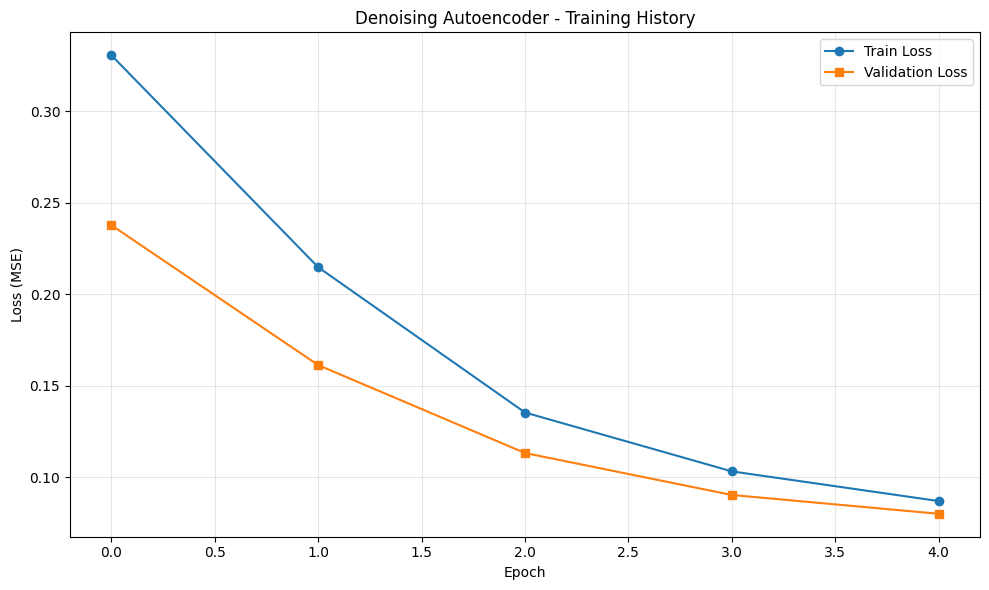

Final Train Loss: 0.087125
Final Val Loss: 0.080161


In [10]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Denoising Autoencoder - Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.6f}")
print(f"Final Val Loss: {val_losses[-1]:.6f}")

## 7. Visualize Results

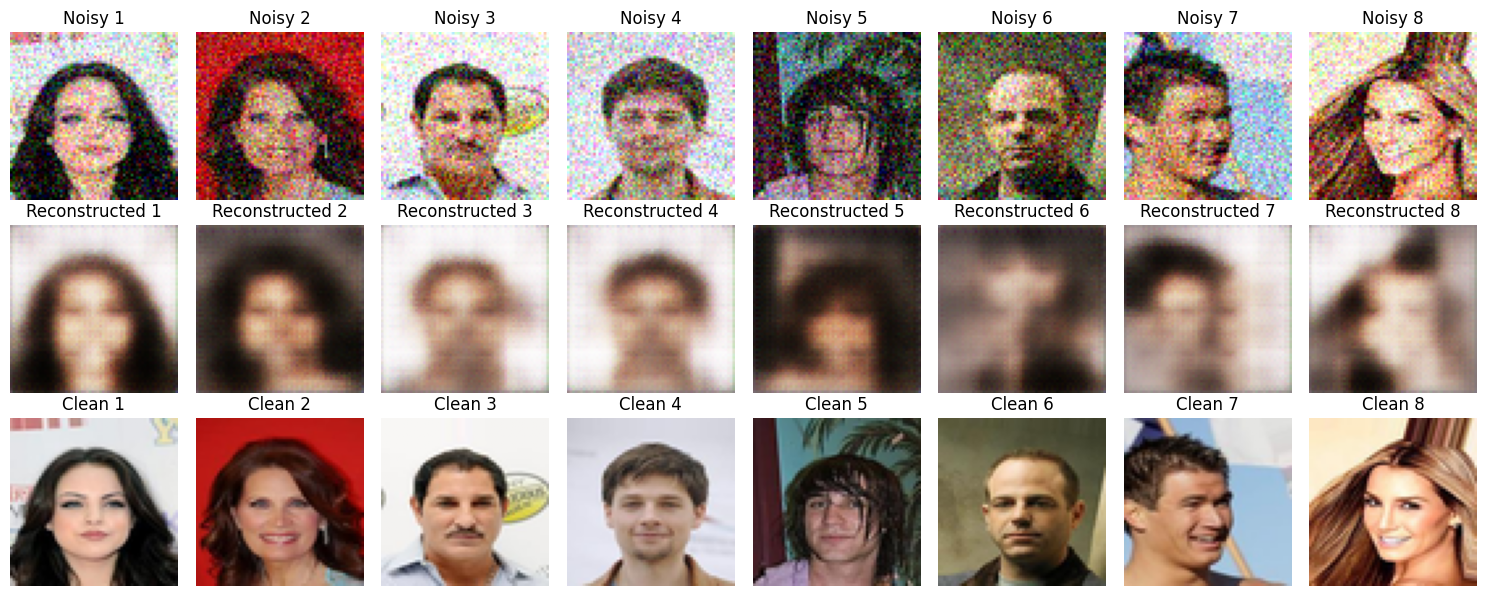

In [11]:
def visualize_results(model, val_loader, device, num_samples=8):
    model.eval()
    
    # Get a batch
    noisy_images, clean_images = next(iter(val_loader))
    noisy_images = noisy_images[:num_samples].to(device)
    clean_images = clean_images[:num_samples].to(device)
    
    # Generate reconstructions
    with torch.no_grad():
        reconstructed = model(noisy_images)
    
    # Denormalize for visualization (from [-1, 1] to [0, 1])
    def denormalize(img):
        return (img + 1) / 2
    
    noisy_images = denormalize(noisy_images)
    clean_images = denormalize(clean_images)
    reconstructed = denormalize(reconstructed)
    
    # Create grid
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 6))
    
    for i in range(num_samples):
        # Noisy images
        img_noisy = noisy_images[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(img_noisy, 0, 1))
        axes[0, i].set_title(f'Noisy {i+1}')
        axes[0, i].axis('off')
        
        # Reconstructed images
        img_recon = reconstructed[i].cpu().permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(img_recon, 0, 1))
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')
        
        # Clean images
        img_clean = clean_images[i].cpu().permute(1, 2, 0).numpy()
        axes[2, i].imshow(np.clip(img_clean, 0, 1))
        axes[2, i].set_title(f'Clean {i+1}')
        axes[2, i].axis('off')
    
    axes[0, 0].set_ylabel('Noisy Input', fontsize=12)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
    axes[2, 0].set_ylabel('Clean Target', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Visualize results
visualize_results(model, val_loader, device, num_samples=8)

## 8. Save the Model

In [ ]:
# Save model checkpoint
model_path = './denoising_autoencoder_model.pth'
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, model_path)

print(f"Model saved to {model_path}")

## 9. Load and Test Saved Model

In [ ]:
# Load model
def load_model(checkpoint_path, device):
    model = DenoisingAutoencoder().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

# Load and test
loaded_model = load_model(model_path, device)
print(f"Model loaded from {model_path}")
print(f"Total epochs trained: {checkpoint['epoch']}")

# Test on validation set
test_loss = validate(loaded_model, val_loader, criterion, device)
print(f"Test Loss: {test_loss:.6f}")